## Cloudy – Exploring Simulation Suite

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['axes.formatter.use_mathtext'] = True

### Broad Line Regions

```
../Cloudy/source/cloudy.exe < blr.in > blr.out
```

In [2]:
blr_df = pd.read_table('blr.con')

blr_df = blr_df.rename(columns={'#Cont  nu': 'wavel'})

In [3]:
blr_df.iloc[5000:5010].style.hide_index()

wavel,incident,trans,DiffOut,net trans,reflc,total,reflin,outlin,lineID,cont,nLine
1.732370,68910000.000000,68500000.000000,3461000.000000,71960000.000000,3791000.000000,75750000.000000,131800.000000,130800.000000,He 1,,1500.160000
1.726610,68910000.000000,68500000.000000,3334000.000000,71830000.000000,3662000.000000,75490000.000000,216.600000,215.800000,Ni 2,,1500.160000
1.720860,68910000.000000,68500000.000000,3336000.000000,71830000.000000,3665000.000000,75500000.000000,8.017000,7.552000,C 6,,1800.200000
1.715140,68910000.000000,68500000.000000,3353000.000000,71850000.000000,3682000.000000,75530000.000000,13370.000000,13290.000000,Fe 2,,2100.230000
1.709430,68910000.000000,68500000.000000,3375000.000000,71870000.000000,3745000.000000,75620000.000000,73870.000000,32250.000000,Mg 1,,2100.230000
1.703740,68910000.000000,68400000.000000,3405000.000000,71810000.000000,3734000.000000,75540000.000000,59920.000000,59320.000000,He 2,,6000.660000
1.698070,68910000.000000,68500000.000000,7395000.000000,75900000.000000,7872000.000000,83770000.000000,4194000.000000,4047000.000000,He 1,,2700.300000
1.692420,68910000.000000,68500000.000000,3629000.000000,72130000.000000,3961000.000000,76090000.000000,280400.000000,277700.000000,He 2,,3300.360000
1.686790,68910000.000000,68320000.000000,3354000.000000,71670000.000000,3683000.000000,75350000.000000,0.046370,0.021420,N 1,,900.100000
1.681180,68910000.000000,66950000.000000,7905000.000000,74850000.000000,10930000.000000,85790000.000000,7248000.000000,4548000.000000,H 1,,5400.590000


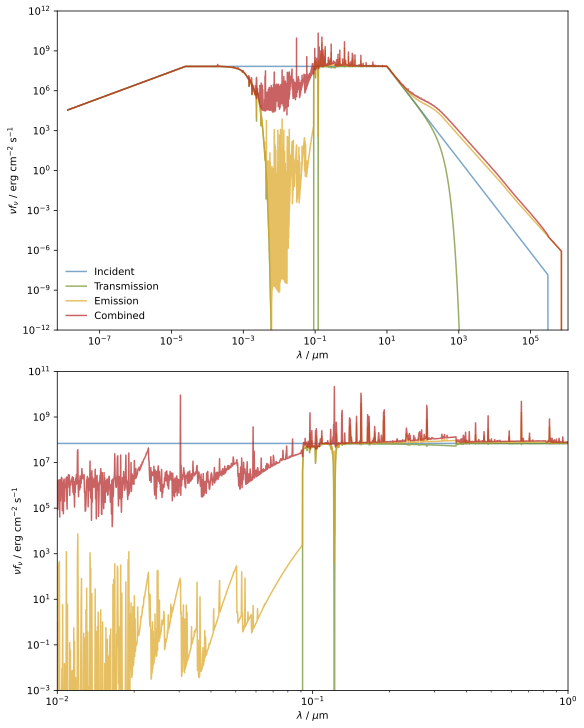

In [4]:
fig, axs = plt.subplots(2, 1, figsize=[8, 10])

lam = np.array(blr_df['wavel'])

inc = np.array(blr_df['incident'])
tra = np.array(blr_df['trans'])
emi = np.array(blr_df['net trans'])
com = np.array(blr_df['total'])

axs[0].plot(lam, inc, c='steelblue', label='Incident', alpha=0.7)
axs[0].plot(lam, tra, c='olivedrab', label='Transmission', alpha=0.7)
axs[0].plot(lam, emi, c='goldenrod', label='Emission', alpha=0.7)
axs[0].plot(lam, com, c='firebrick', label='Combined', alpha=0.7)

axs[0].set_xlim(6.6e-9, 1.1e6)
axs[0].set_ylim(1e-12, 1e12)

axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[0].set_xlabel(r'$\lambda$ / $\mu$m')
axs[0].set_ylabel(r'$\nu f_\nu$ / erg cm$^{-2}$ s$^{-1}$')

axs[0].legend(loc='lower left')

low = 1e-2
up = 1e0

axs[1].plot(lam[(lam > low) & (lam < up)], inc[(lam > low) & (lam < up)], c='steelblue', alpha=0.7)
axs[1].plot(lam[(lam > low) & (lam < up)], tra[(lam > low) & (lam < up)], c='olivedrab', alpha=0.7)
axs[1].plot(lam[(lam > low) & (lam < up)], emi[(lam > low) & (lam < up)], c='goldenrod', alpha=0.7)
axs[1].plot(lam[(lam > low) & (lam < up)], com[(lam > low) & (lam < up)], c='firebrick', alpha=0.7)

axs[1].set_xlim(low, up)
axs[1].set_ylim(1e-3, 1e11)

axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[1].set_xlabel(r'$\lambda$ / $\mu$m')
axs[1].set_ylabel(r'$\nu f_\nu$ / erg cm$^{-2}$ s$^{-1}$')

plt.show()
plt.close()